# Data Skewness & Statistical Analysis
**ShipmentSure — Predicting On-Time Delivery**

We measure and visualize non-normality (skewness) in numeric features
and check how distributions align with delivery outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
# Skewness, mean, median, mode for each numeric column
num_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

stats_df = pd.DataFrame({
    'Mean': df[num_cols].mean().round(3),
    'Median': df[num_cols].median().round(3),
    'Mode': df[num_cols].mode().iloc[0].round(3),
    'Skewness': df[num_cols].skew().round(3),
    'Std': df[num_cols].std().round(3)
})
print("Statistical summary:")
stats_df

Statistical summary:


,Mean,Median,Mode,Skewness,Std
Customer_care_calls,4.523,5.0,6,-0.028,1.731
Customer_rating,2.981,3.0,2,0.027,1.424
Cost_of_the_Product,200.316,202.5,273,-0.020,62.730
Prior_purchases,5.984,6.0,8,-0.016,2.574
Discount_offered,31.987,32.0,41,0.035,18.507
Weight_in_gms,3501.413,3544.0,1722,-0.059,1407.925


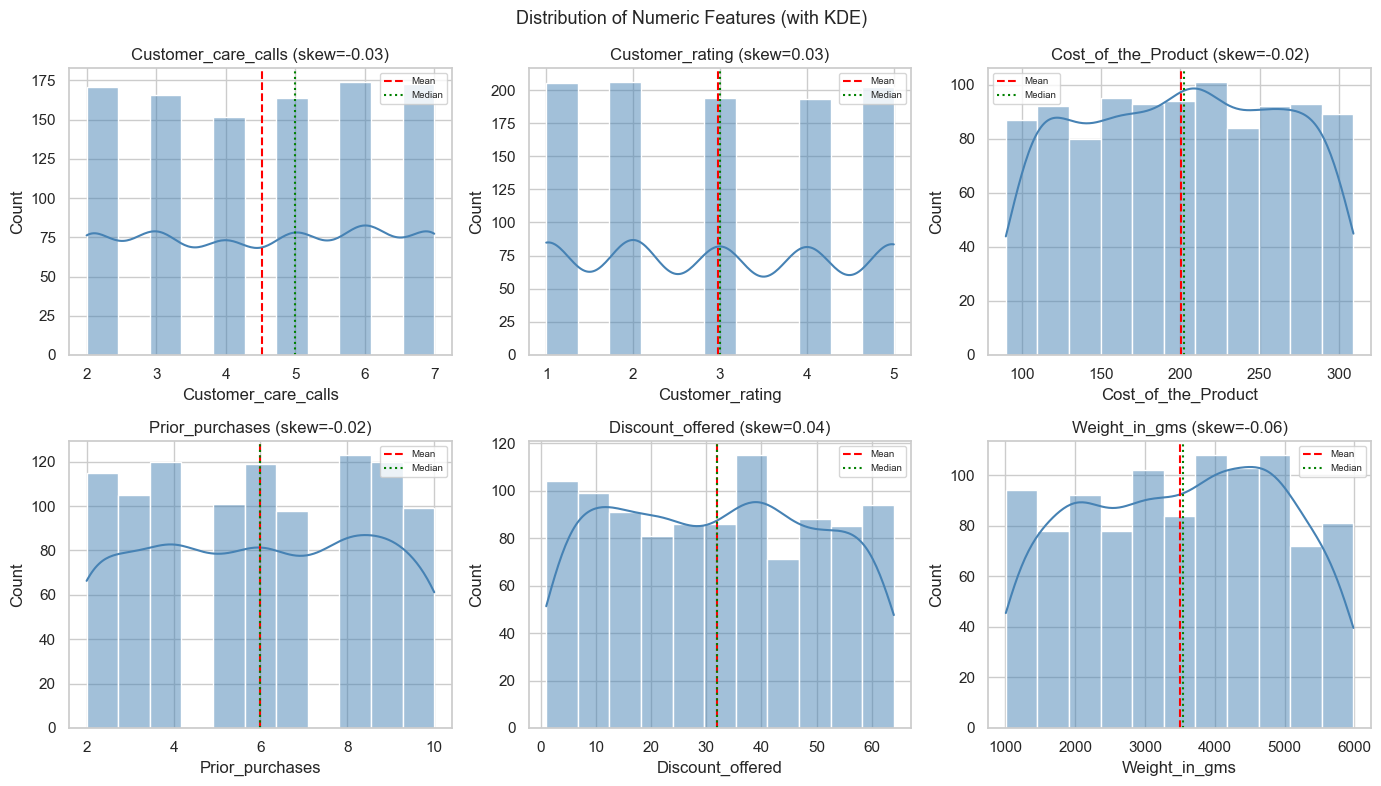

In [4]:
# Histograms with KDE — visualize skewness
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribution of Numeric Features (with KDE)', fontsize=13)

for idx, col in enumerate(num_cols):
    ax = axes[idx // 3][idx % 3]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(df[col].median(), color='green', linestyle=':', label='Median')
    ax.set_title(f'{col} (skew={df[col].skew():.2f})')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

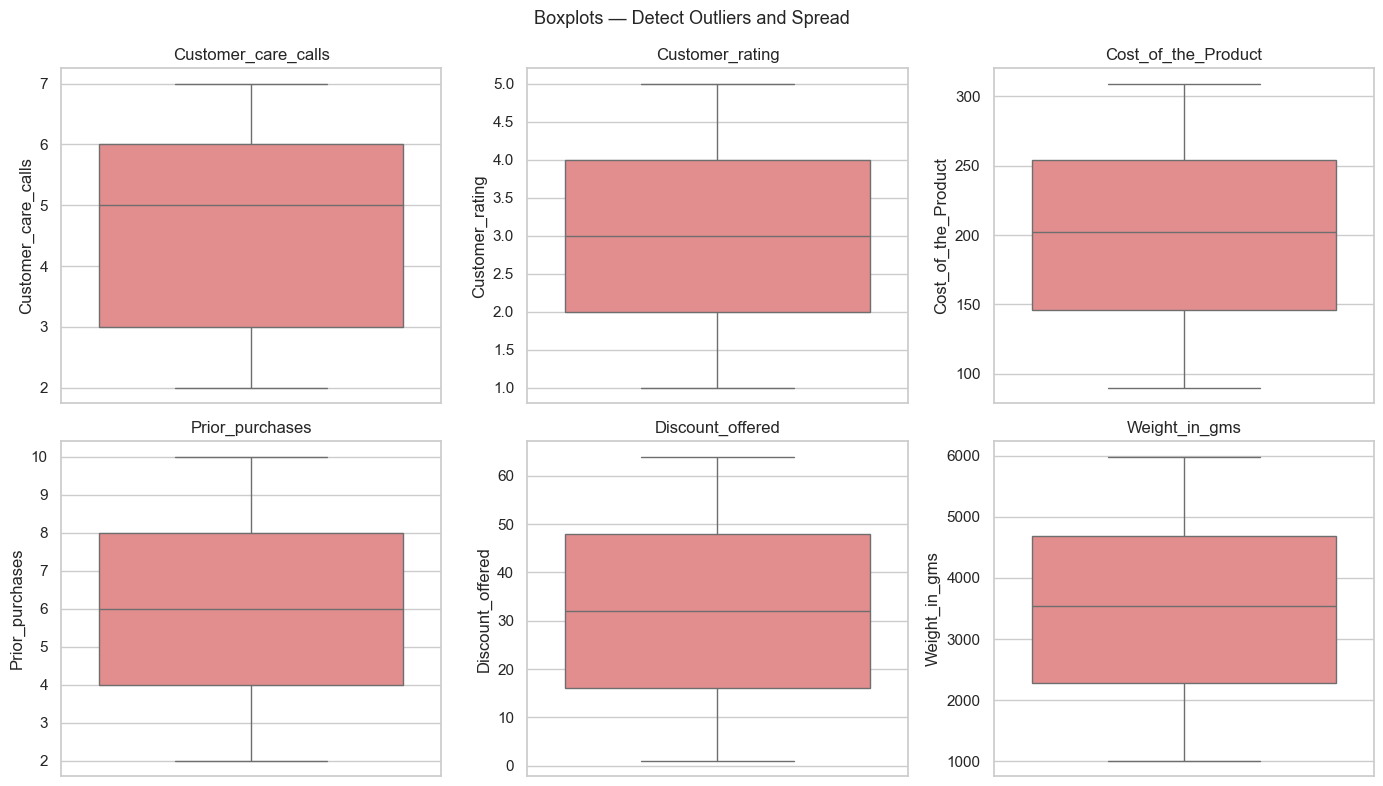

In [5]:
# Boxplots per feature
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots — Detect Outliers and Spread', fontsize=13)

for idx, col in enumerate(num_cols):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(data=df, y=col, ax=ax, color='lightcoral')
    ax.set_title(col)

plt.tight_layout()
plt.show()

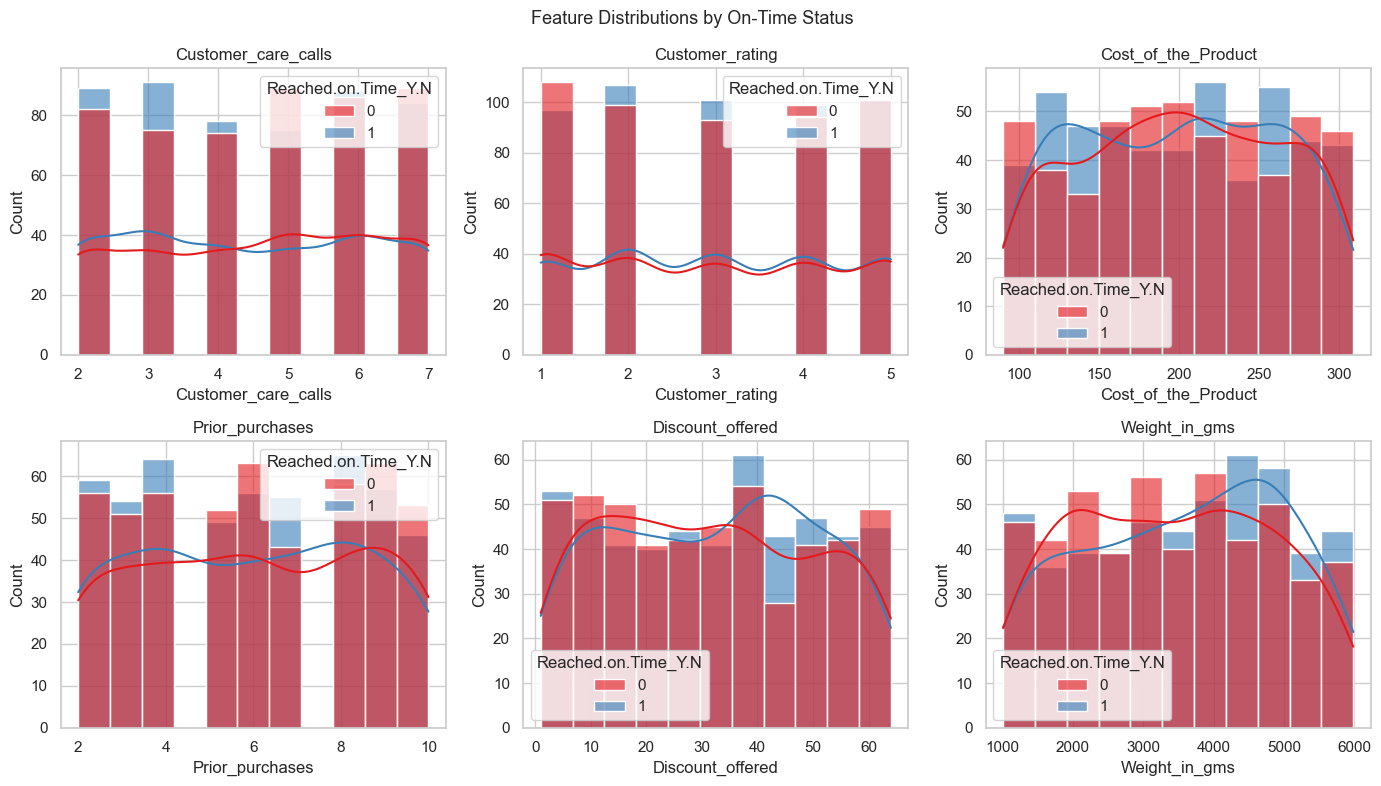

In [6]:
# Distribution by delivery outcome (hue)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions by On-Time Status', fontsize=13)

for idx, col in enumerate(num_cols):
    ax = axes[idx // 3][idx % 3]
    sns.histplot(data=df, x=col, hue='Reached.on.Time_Y.N', kde=True, ax=ax,
                 palette='Set1', alpha=0.6)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [7]:
# Log transform to check if it reduces skewness
df['log_Cost'] = np.log1p(df['Cost_of_the_Product'])
df['log_Discount'] = np.log1p(df['Discount_offered'])
df['log_Weight'] = np.log1p(df['Weight_in_gms'])

print("Before vs After Log Transform Skewness:")
comparison = pd.DataFrame({
    'Original': df[['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']].skew(),
    'Log Transformed': df[['log_Cost', 'log_Discount', 'log_Weight']].skew()
}).round(3)
comparison.index = ['Cost', 'Discount', 'Weight']
print(comparison)

Before vs After Log Transform Skewness:


ValueError: Length mismatch: Expected axis has 6 elements, new values have 3 elements

In [ ]:
# Before/After log transform visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Cost_of_the_Product'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f'Cost (original, skew={df["Cost_of_the_Product"].skew():.2f})')

sns.histplot(df['log_Cost'], kde=True, ax=axes[1], color='teal')
axes[1].set_title(f'log(Cost) (skew={df["log_Cost"].skew():.2f})')

plt.tight_layout()
plt.show()